# Introduction to Clustering — K-Means & DBSCAN

## 1. Supervised vs Unsupervised Learning

Everything we have done so far — Linear Regression, Logistic Regression, SVM, Decision Trees, Random Forest — has been **supervised learning**. In supervised learning, every training sample has a **label** (the target variable $y$) that tells the model the right answer. The model learns the mapping from features to labels.

Today we step into a fundamentally different world: **unsupervised learning**. Here, there are **no labels**. The model receives only the features $X$ and must discover patterns, structure, and groupings on its own.

Think of the difference like this:
- **Supervised:** A teacher gives you labeled flashcards ("this is a cat", "this is a dog"). You learn the rules.
- **Unsupervised:** You are given a pile of unlabeled photos and asked: "What natural groups do you see?" Nobody tells you the answer — you discover it.

### What is Clustering?

**Clustering** is the most common unsupervised learning task. The goal is to group data points into **clusters** such that:
- Points within the same cluster are **similar** to each other
- Points in different clusters are **different** from each other

### Real-World Applications

- **Customer segmentation** — Group customers by purchasing behavior for targeted marketing
- **Document/topic grouping** — Automatically organize news articles by topic
- **Anomaly detection** — Points that do not fit any cluster may be outliers or fraud
- **Image compression** — Group similar pixel colors to reduce image size
- **Gene expression analysis** — Group genes with similar activity patterns
- **Social network analysis** — Find communities in networks

## 2. K-Means Clustering

K-Means is the simplest and most widely used clustering algorithm. The name tells you what it does: it finds **K** clusters, each defined by its **mean** (center point, called the **centroid**).

### The Algorithm — Step by Step

1. **Choose K** — You decide in advance how many clusters you want.

2. **Initialize centroids** — Randomly place K centroids in the feature space. (Scikit-learn uses a smarter initialization called `k-means++` that spreads them out.)

3. **Assign** — For each data point, compute its distance to all K centroids. Assign the point to the **nearest** centroid. Now every point belongs to a cluster.

4. **Update** — For each cluster, compute the **mean** of all points assigned to it. This mean becomes the new centroid.

5. **Repeat** steps 3 and 4 until the centroids stop moving (or move less than a threshold). This is called **convergence**.

### Key Properties

- K-Means finds **spherical (globular)** clusters — it assumes clusters are roughly round and similar in size
- It uses **Euclidean distance** by default
- It is **sensitive to initialization** — different random starts can give different results (Scikit-learn runs multiple initializations and picks the best)
- It is **fast** — scales well to large datasets
- **You must specify K** in advance — the algorithm does not figure it out for you

### Weaknesses

- Cannot find non-spherical clusters (crescents, rings, irregular shapes)
- Sensitive to outliers — a single extreme point can pull a centroid away
- Assumes clusters are similar in size and density
- Requires you to choose K

## 3. How to Choose K — The Elbow Method and Silhouette Score

### The Elbow Method

K-Means minimizes a metric called **inertia** (also called WCSS — Within-Cluster Sum of Squares). Inertia measures how tightly points cluster around their centroids:

$$\text{Inertia} = \sum_{i=1}^{n} ||x_i - c_{\text{nearest}}||^2$$

Lower inertia = tighter clusters. But inertia always decreases as K increases (in the extreme, K=n gives inertia=0 because every point is its own cluster). We look for the **elbow** — the point where adding more clusters stops significantly reducing inertia.

### Silhouette Score

The Silhouette Score measures how well each point fits within its assigned cluster compared to other clusters. For each point:

$$s = \frac{b - a}{\max(a, b)}$$

Where:
- $a$ = average distance to other points **in the same cluster** (cohesion)
- $b$ = average distance to points in the **nearest different cluster** (separation)

- $s = +1$ → point is perfectly matched to its cluster
- $s = 0$ → point is on the boundary between clusters
- $s = -1$ → point is in the wrong cluster

The **average silhouette score** across all points gives an overall measure of clustering quality. We pick K that maximizes this score.

## 4. DBSCAN — Density-Based Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) takes a completely different approach from K-Means. Instead of assuming round clusters, it finds clusters based on **density** — regions where points are closely packed together.

### The Concept

DBSCAN defines three types of points:

1. **Core points** — Points that have at least `min_samples` neighbors within a radius of `eps` (epsilon). These are in the dense interior of a cluster.

2. **Border points** — Points within `eps` of a core point but not core points themselves. They are on the edge of a cluster.

3. **Noise points** — Points that are not within `eps` of any core point. They do not belong to any cluster. DBSCAN labels these as **-1**.

### The Algorithm

1. Pick any unvisited point
2. Find all points within distance `eps`
3. If ≥ `min_samples` neighbors → it is a core point. Start a new cluster and expand it by recursively including all density-reachable points
4. If < `min_samples` neighbors → mark as noise (for now; it may later be included as a border point)
5. Repeat until all points are visited

### Key Parameters

- **`eps`** (epsilon) — The radius of the neighborhood. Too small = most points are noise. Too large = all points merge into one cluster.
- **`min_samples`** — Minimum points to form a dense region. Higher values = fewer, denser clusters.

### Strengths vs K-Means

| Aspect | K-Means | DBSCAN |
|--------|---------|--------|
| **Cluster shape** | Spherical only | Arbitrary shapes |
| **Number of clusters** | Must specify K | Discovers automatically |
| **Noise handling** | None (assigns all points) | Detects noise/outliers |
| **Density** | Assumes uniform | Handles varying density |
| **Speed** | Very fast | Slower on large datasets |
| **Scaling** | Needs scaling | Needs scaling |

---

## 5. Setup and Imports

**Task:** Import all required libraries.

In [1]:
# Import numpy, pandas, matplotlib.pyplot, seaborn

# From sklearn.cluster import KMeans, DBSCAN

# From sklearn.preprocessing import StandardScaler

# From sklearn.metrics import silhouette_score, silhouette_samples

# From sklearn.datasets import make_blobs, make_moons, load_breast_cancer

# From sklearn.decomposition import PCA

# Set seaborn style and random seed (42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs, make_moons, make_circles, load_breast_cancer
from sklearn.decomposition import PCA

# sns.set_style('whitegrid')
# np.random.seed(42)

# print("All libraries imported successfully!")

---

## 6. K-Means on Simple 2D Data

Let us start with synthetic data where we **know** the true clusters, so we can see exactly what K-Means does.

### 6.1 Generate Blob Data

`make_blobs` creates nicely separated spherical clusters — the ideal case for K-Means.

**Task:** Generate 3-cluster blob data and visualize it.

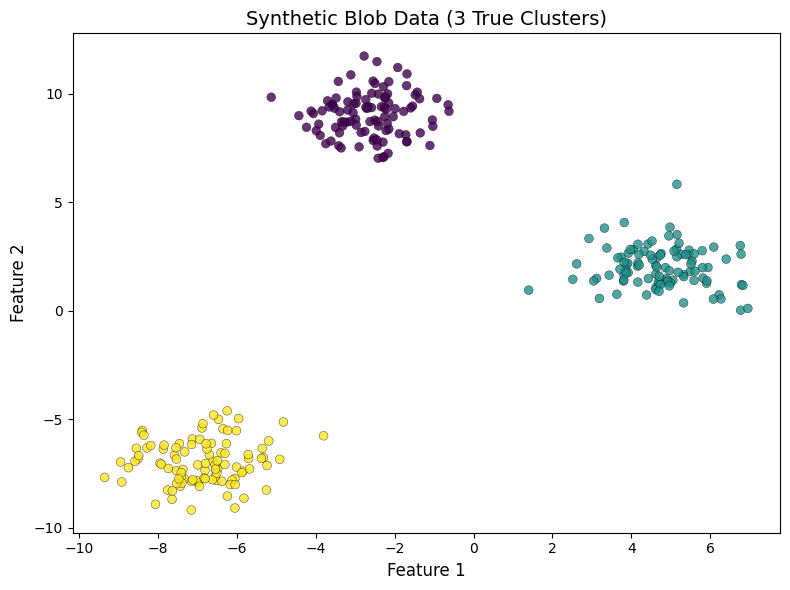

Generated 300 samples with 3 true clusters


In [2]:
# Generate 300 samples with 3 centers using make_blobs
# Set cluster_std=1.0, random_state=42

# Create a scatter plot colored by true labels
# figsize=(8, 6)
# Add title: 'Synthetic Blob Data (3 True Clusters)'
# Show the plot


X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis',
            s=40, edgecolors='k', linewidth=0.3, alpha=0.8)
plt.title('Synthetic Blob Data (3 True Clusters)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Generated {X_blobs.shape[0]} samples with 3 true clusters")


### 6.2 Fit K-Means with K=3

Now let us fit K-Means and see if it recovers the true clusters.

**Task:** Fit KMeans(n_clusters=3) and visualize the results.

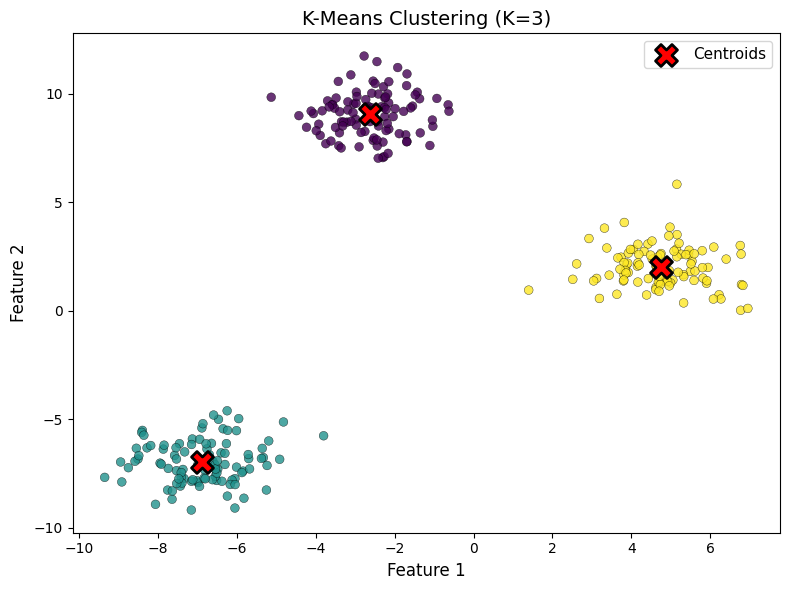

Inertia (WCSS):    566.86
Silhouette Score:  0.8480
Iterations:        2


In [3]:
# Create KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit and predict cluster labels

# Access the centroids: kmeans.cluster_centers_

# Create a scatter plot:
#   Color points by predicted cluster labels
#   Mark centroids with large red 'X' markers
# figsize=(8, 6)
# Add title: 'K-Means Clustering (K=3)'
# Show the plot

# Print inertia: kmeans.inertia_
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans_3.fit_predict(X_blobs)
centroids = kmeans_3.cluster_centers_



plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=km_labels, cmap='viridis',
            s=40, edgecolors='k', linewidth=0.3, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X',
            s=250, edgecolors='black', linewidth=2, label='Centroids', zorder=5)
plt.title('K-Means Clustering (K=3)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

sil = silhouette_score(X_blobs, km_labels)
print(f"Inertia (WCSS):    {kmeans_3.inertia_:.2f}")
print(f"Silhouette Score:  {sil:.4f}")
print(f"Iterations:        {kmeans_3.n_iter_}")


**What to observe:** K-Means should perfectly recover the three blob clusters. The centroids (red X) are at the center of each cluster. The inertia tells us how tight the clusters are, and the silhouette score should be high (>0.5) indicating well-separated clusters.

### 6.3 What Happens with Wrong K?

What if we pick the wrong number of clusters? Let us try K=2 and K=5 to see what goes wrong.

**Task:** Fit K-Means with K=2, K=3, K=5 and compare.

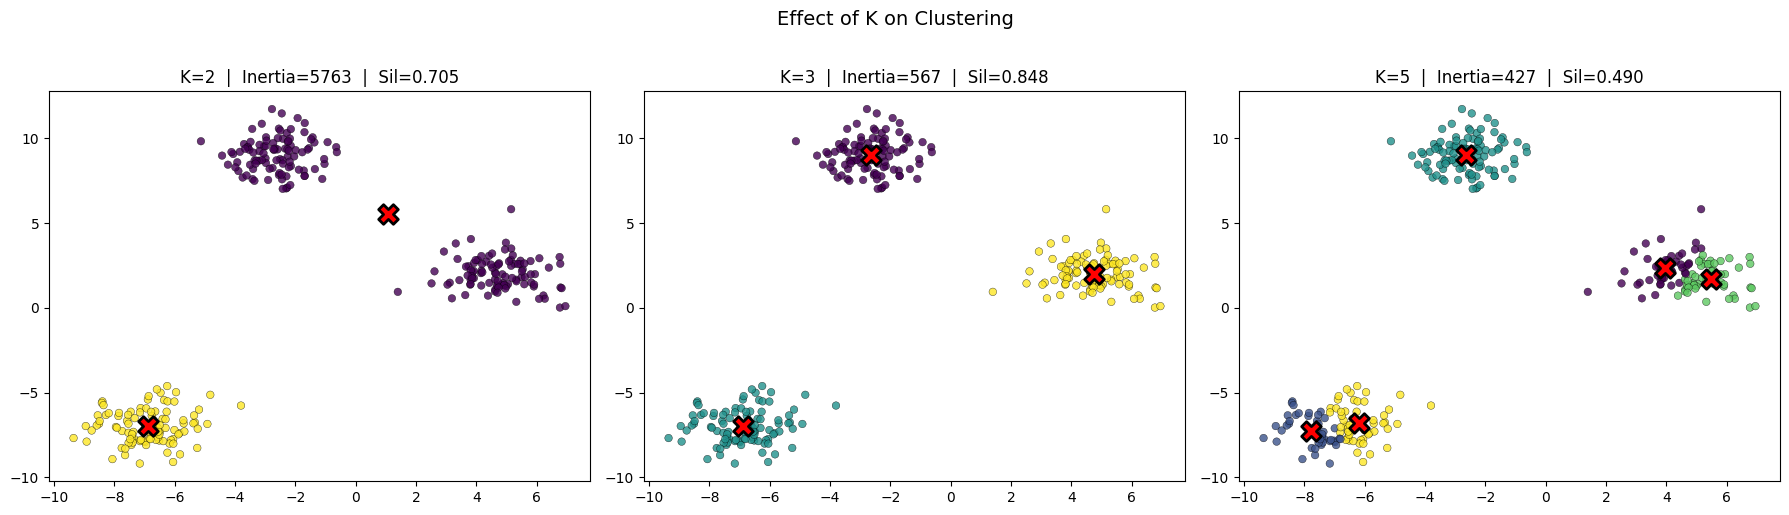

In [4]:
# Create a figure with 1 row, 3 columns, figsize=(18, 5)

# For K in [2, 3, 5]:
#   Fit KMeans(n_clusters=K)
#   Plot clusters colored by labels with centroids
#   Include inertia and silhouette score in the title

# plt.tight_layout() and plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate([2, 3, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_blobs)
    sil_k = silhouette_score(X_blobs, labels)

    axes[i].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels, cmap='viridis',
                     s=30, edgecolors='k', linewidth=0.3, alpha=0.8)
    axes[i].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                     c='red', marker='X', s=200, edgecolors='black', linewidth=2)
    axes[i].set_title(f'K={k}  |  Inertia={km.inertia_:.0f}  |  Sil={sil_k:.3f}', fontsize=12)

plt.suptitle('Effect of K on Clustering', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**What to observe:** With K=2, K-Means merges two clusters into one — losing important structure. With K=5, it splits natural clusters into artificial sub-groups. K=3 gives the best silhouette score and matches the true structure. Choosing the right K is critical.

---

## 7. Finding the Optimal K

### 7.1 The Elbow Method

**Task:** Plot inertia for K=1 to K=10 and look for the elbow.

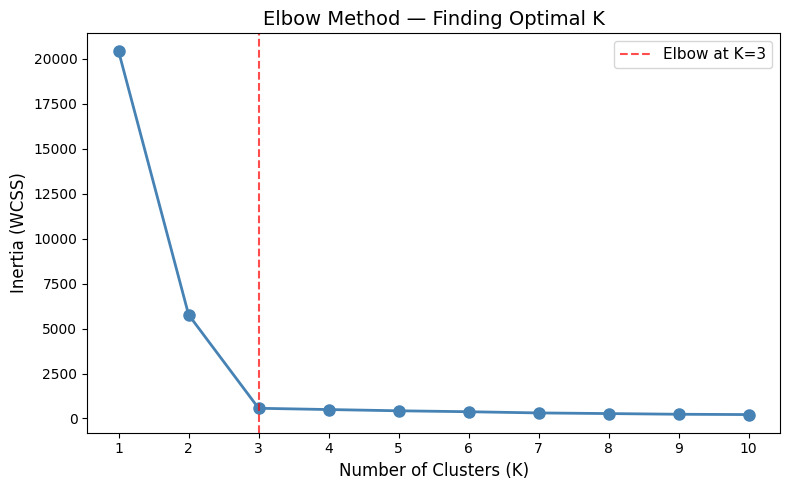

In [5]:
# For K in range(1, 11):
#   Fit KMeans and store inertia

# Plot K vs Inertia with figsize=(8, 5)
# Use markers and lines
# Add title: 'Elbow Method — Finding Optimal K'
# Add labels
# Show the plot

inertias  = []
K_range = range(1,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Elbow at K=3')
plt.title('Elbow Method — Finding Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(K_range)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


**What to observe:** The curve drops steeply at first, then bends at K=3 — the "elbow." After K=3, adding more clusters gives diminishing returns. The elbow suggests K=3 is optimal, which matches our known truth.

### 7.2 Silhouette Score Method

**Task:** Plot silhouette scores for K=2 to K=10.

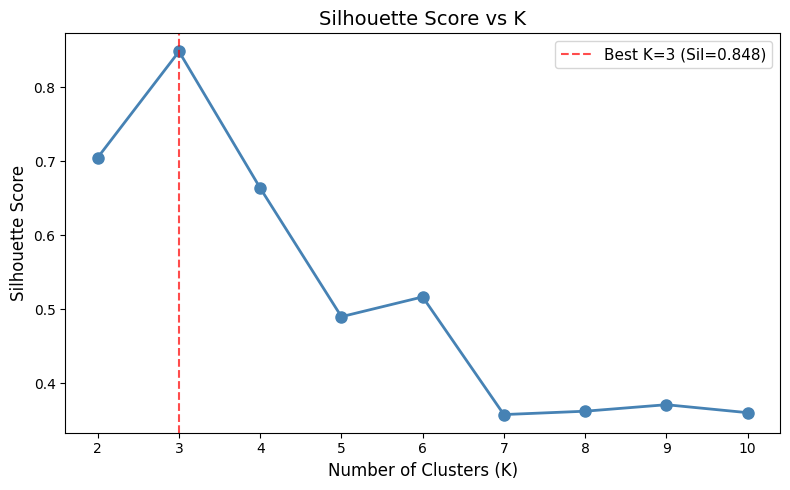

Optimal K by Silhouette: 3 (score=0.8480)


In [13]:
sil_scores = []
K_sil = range(2, 11)

for k in K_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_blobs)
    sil_scores.append(silhouette_score(X_blobs, labels))

best_k = list(K_sil)[np.argmax(sil_scores)]

plt.figure(figsize=(8, 5))
plt.plot(K_sil, sil_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
            label=f'Best K={best_k} (Sil={max(sil_scores):.3f})')
plt.title('Silhouette Score vs K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(K_sil)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Optimal K by Silhouette: {best_k} (score={max(sil_scores):.4f})")

**What to observe:** The silhouette score should peak at K=3. This gives a cleaner signal than the elbow method — the maximum is unambiguous.

---

## 8. K-Means Fails — Non-Spherical Clusters

K-Means assumes spherical clusters. What happens when clusters have complex shapes? Let us use `make_moons` (crescent shapes) to expose this weakness.

**Task:** Generate moon data and apply K-Means.

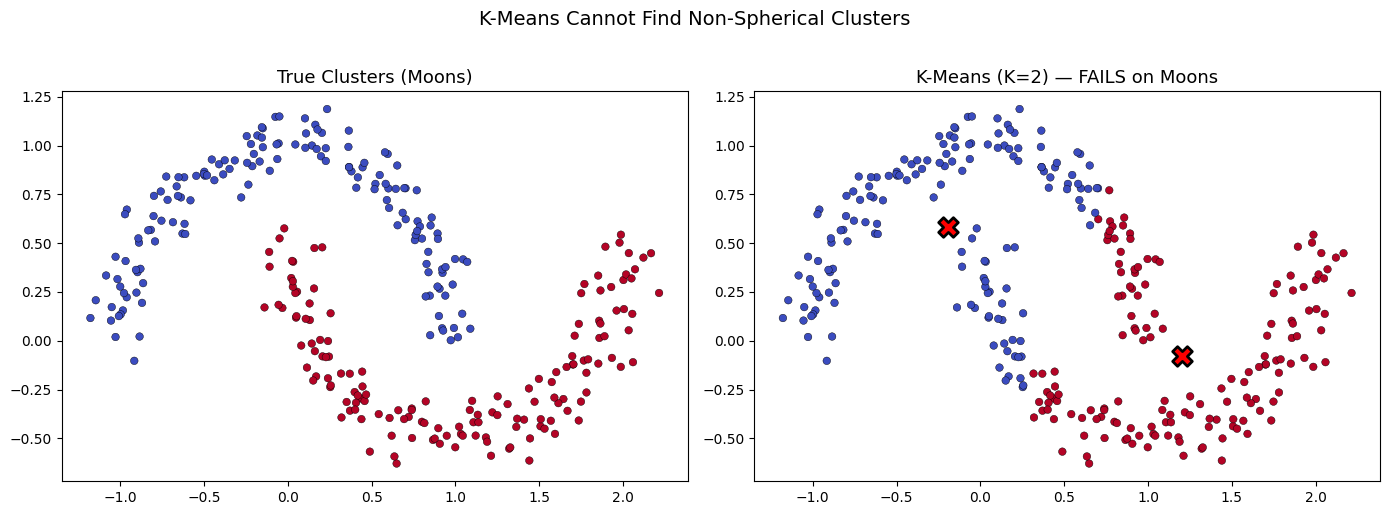

In [14]:
# # Generate 300 moon-shaped samples with noise=0.08

# # Create a figure with 1 row, 2 columns, figsize=(14, 5)

# # Left: scatter plot with true labels
# # Title: 'True Clusters (Moons)'

# # Right: Fit KMeans(n_clusters=2) and plot predicted clusters
# # Title: 'K-Means on Moon Data — FAILS'

# # plt.tight_layout() and plt.show()


X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=42)

km_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
km_moon_labels = km_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm',
                s=30, edgecolors='k', linewidth=0.3)
axes[0].set_title('True Clusters (Moons)', fontsize=13)

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moon_labels, cmap='coolwarm',
                s=30, edgecolors='k', linewidth=0.3)
axes[1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
                c='red', marker='X', s=200, edgecolors='black', linewidth=2)
axes[1].set_title('K-Means (K=2) — FAILS on Moons', fontsize=13)

plt.suptitle('K-Means Cannot Find Non-Spherical Clusters', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**What to observe:** K-Means draws a straight boundary between the two moons — it cannot capture the curved shape. It assigns points to the nearest centroid, but the centroids are in the middle of each half, resulting in a vertical split instead of following the crescent boundaries. This is where DBSCAN shines.

---

## 9. DBSCAN — Density-Based Clustering

### 9.1 DBSCAN on Moon Data

Let us apply DBSCAN to the same moon data and see if it can find the crescent-shaped clusters.

**Task:** Fit DBSCAN on the moon data and visualize.

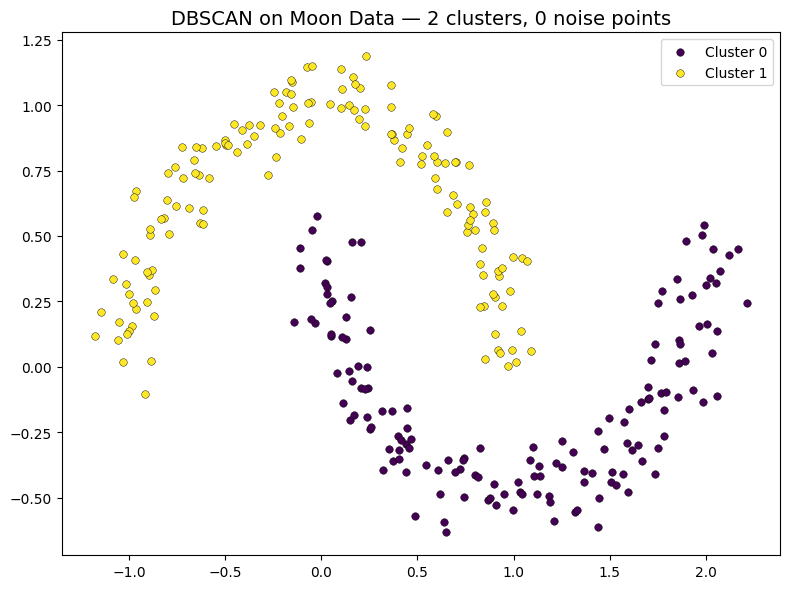

Clusters found: 2
Noise points:   0


In [15]:
# Scale the moon data with StandardScaler

# Fit DBSCAN(eps=0.3, min_samples=5) on scaled data

# Get cluster labels: dbscan.labels_
# Note: -1 means noise

# Create a scatter plot colored by DBSCAN labels
# Use a special color/marker for noise points (-1)
# figsize=(8, 6)
# Add title with number of clusters found and noise points
# Show the plot

# Print: number of clusters, number of noise points


scaler_moons = StandardScaler()
X_moons_sc = scaler_moons.fit_transform(X_moons)

dbscan_moons = DBSCAN(eps=0.3, min_samples=5)
db_moon_labels = dbscan_moons.fit_predict(X_moons_sc)

n_clusters = len(set(db_moon_labels)) - (1 if -1 in db_moon_labels else 0)
n_noise = (db_moon_labels == -1).sum()

plt.figure(figsize=(8, 6))
unique_labels = set(db_moon_labels)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(sorted(unique_labels), colors):
    mask = db_moon_labels == label
    if label == -1:
        plt.scatter(X_moons[mask, 0], X_moons[mask, 1], c='grey', marker='x',
                    s=50, label=f'Noise ({n_noise} pts)', alpha=0.6)
    else:
        plt.scatter(X_moons[mask, 0], X_moons[mask, 1], c=[color], s=30,
                    edgecolors='k', linewidth=0.3, label=f'Cluster {label}')

plt.title(f'DBSCAN on Moon Data — {n_clusters} clusters, {n_noise} noise points', fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise}")

**What to observe:** DBSCAN should correctly identify the two crescent-shaped clusters! Unlike K-Means, it follows the density of points rather than assuming round shapes. It may also identify a few noise points (labeled -1) — these are isolated points that do not belong to any dense region.

### 9.2 Effect of eps on DBSCAN

The `eps` parameter is critical — too small and everything is noise, too large and everything merges.

**Task:** Try different eps values and visualize the effect.

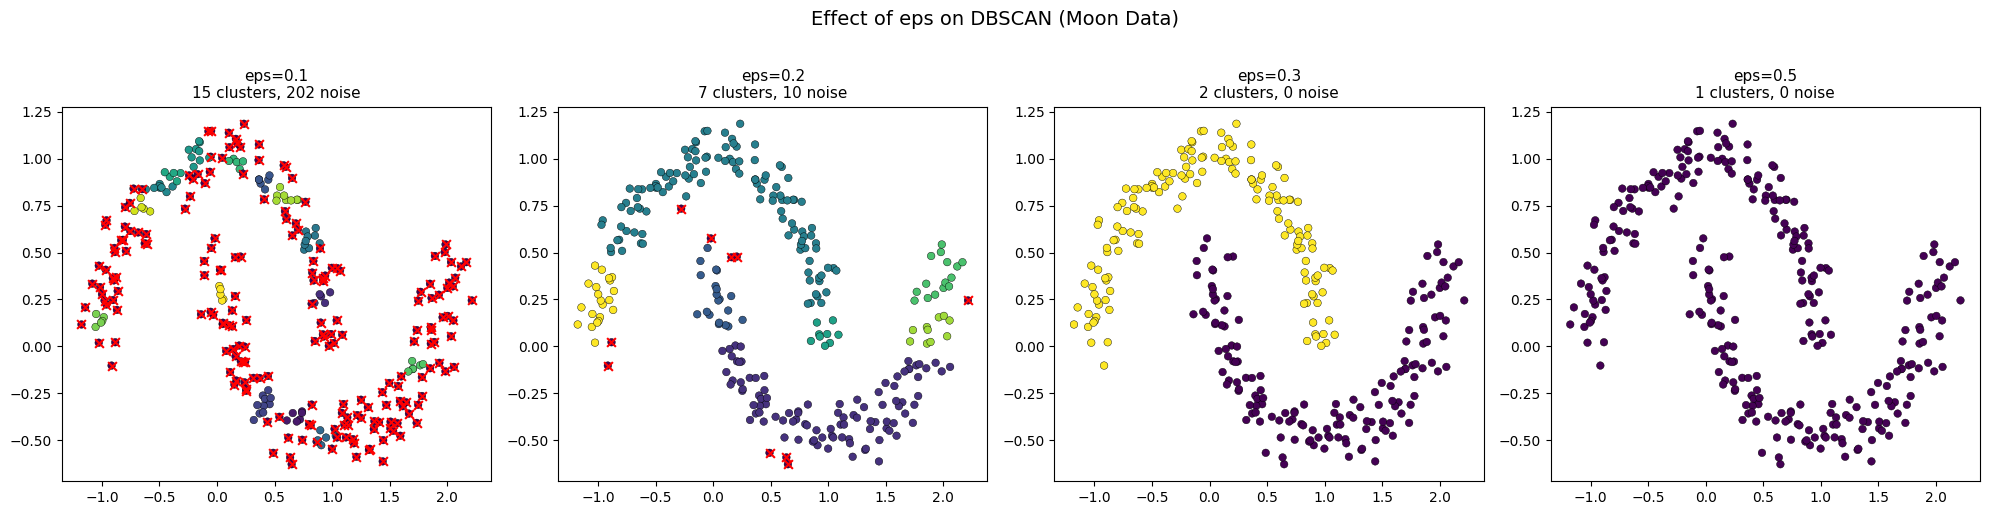

In [16]:
# # Create a figure with 1 row, 4 columns, figsize=(20, 5)

# # For eps in [0.1, 0.2, 0.3, 0.5]:
# #   Fit DBSCAN(eps=eps, min_samples=5) on scaled moon data
# #   Plot clusters
# #   Title: include eps, number of clusters, number of noise points

# # plt.tight_layout() and plt.show()


fig, axes = plt.subplots(1, 4, figsize=(20, 5))

eps_values = [0.1, 0.2, 0.3, 0.5]

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_moons_sc)

    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    n_n = (labels == -1).sum()

    axes[i].scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap='viridis',
                     s=30, edgecolors='k', linewidth=0.3)
    noise_mask = labels == -1
    if noise_mask.any():
        axes[i].scatter(X_moons[noise_mask, 0], X_moons[noise_mask, 1],
                         c='red', marker='x', s=40)

    axes[i].set_title(f'eps={eps}\n{n_c} clusters, {n_n} noise', fontsize=11)

plt.suptitle('Effect of eps on DBSCAN (Moon Data)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**What to observe:**
- **eps=0.1 (too small):** Most points are labeled as noise — the radius is too tight to connect points into clusters.
- **eps=0.2-0.3 (sweet spot):** DBSCAN finds the two moon clusters correctly with minimal noise.
- **eps=0.5 (too large):** Everything merges into one cluster — the radius is so big that points from both moons are considered neighbors.

---

## 10. K-Means vs DBSCAN — Side by Side

Let us create a comprehensive visual comparison on multiple dataset shapes.

**Task:** Compare K-Means and DBSCAN on blobs, moons, and circles.

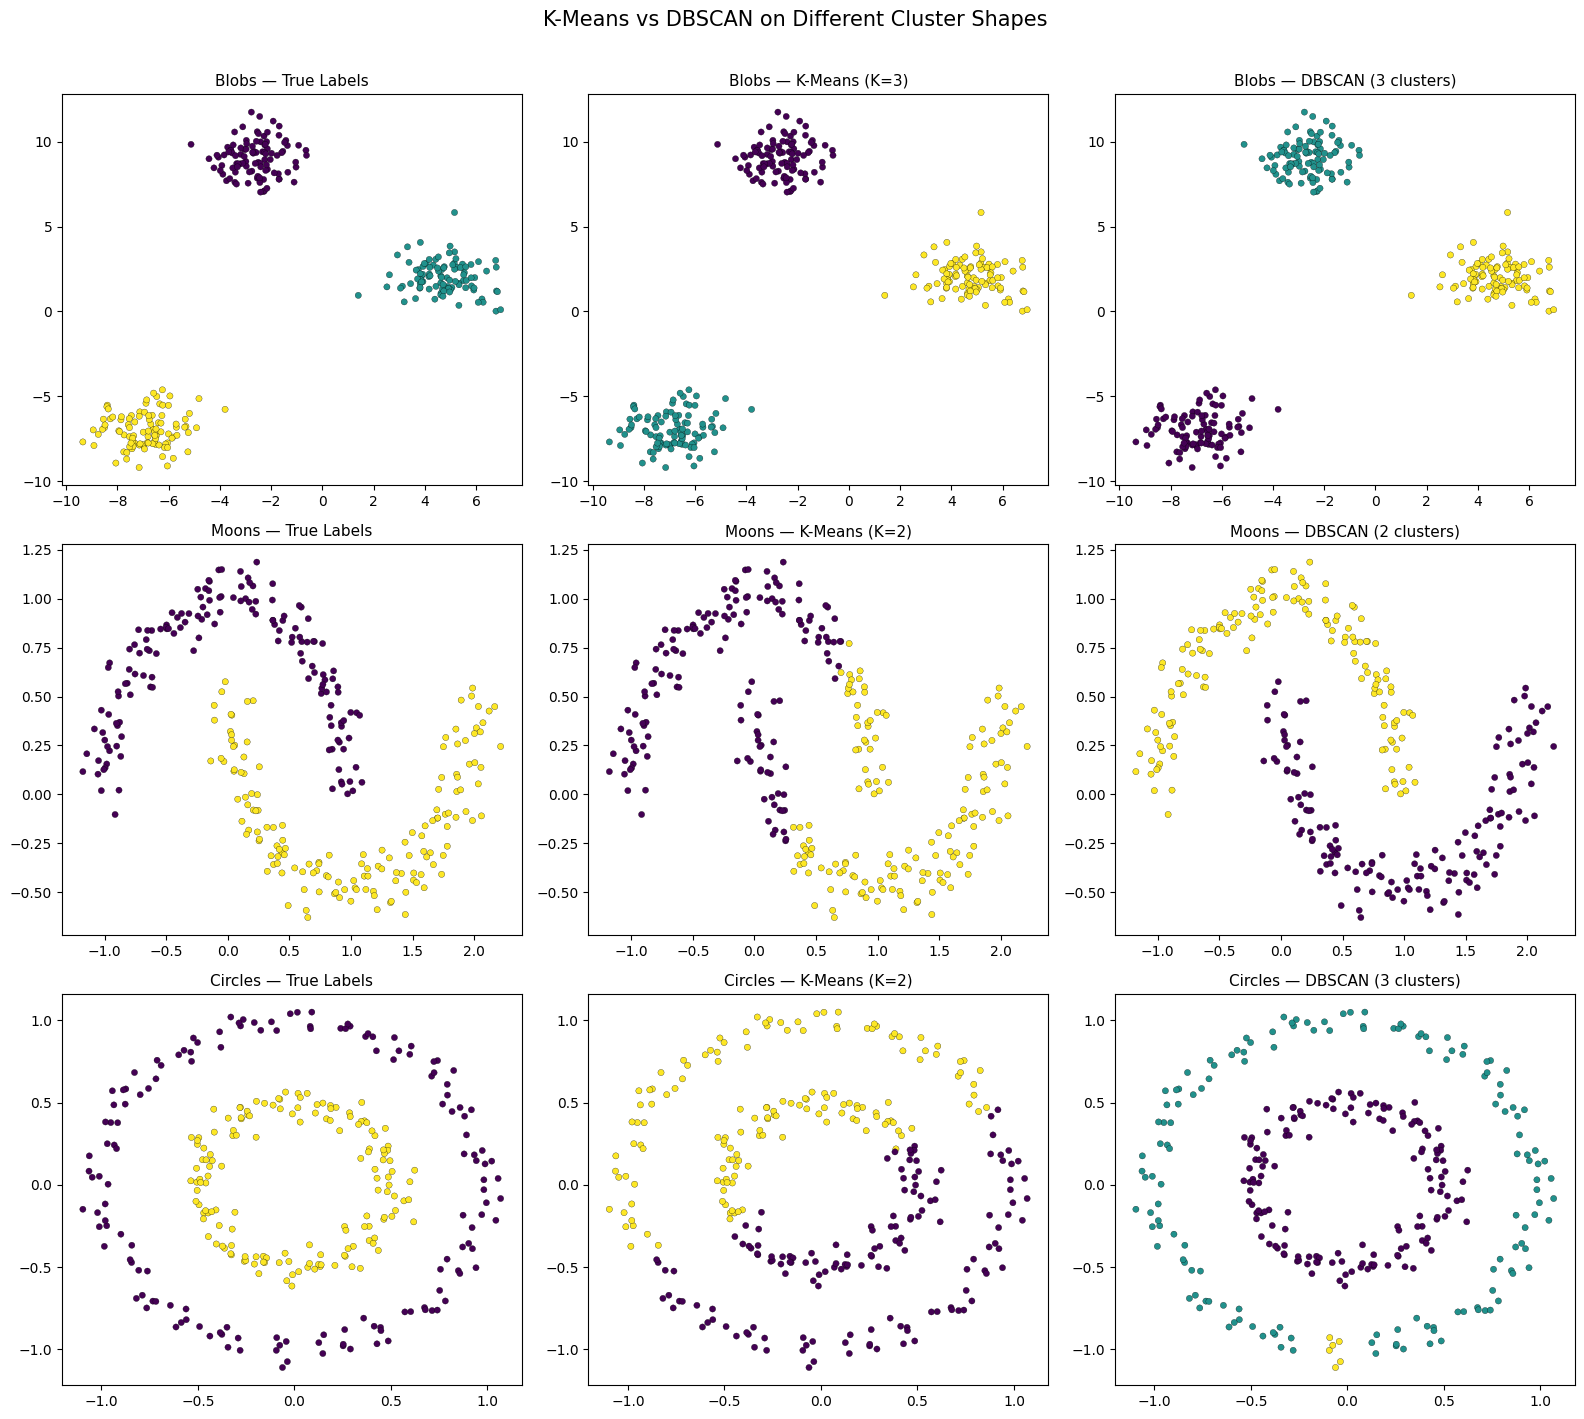

In [18]:
# Import make_circles from sklearn.datasets

# Generate 3 datasets:
#   1. Blobs: make_blobs(300, centers=3, random_state=42)
#   2. Moons: make_moons(300, noise=0.08, random_state=42)
#   3. Circles: make_circles(300, noise=0.05, factor=0.5, random_state=42)

# Create a 3 rows × 3 columns figure, figsize=(18, 15)
#   Column 1: True labels
#   Column 2: K-Means result
#   Column 3: DBSCAN result

# For each dataset, fit both algorithms and plot
# Scale data before DBSCAN
# Choose appropriate K for K-Means, eps for DBSCAN

# plt.tight_layout() and plt.show()


# Generate datasets
X_b, y_b = make_blobs(300, centers=3, cluster_std=1.0, random_state=42)
X_m, y_m = make_moons(300, noise=0.08, random_state=42)
X_c, y_c = make_circles(300, noise=0.05, factor=0.5, random_state=42)

datasets = [
    ('Blobs', X_b, y_b, 3, 0.5),
    ('Moons', X_m, y_m, 2, 0.3),
    ('Circles', X_c, y_c, 2, 0.3)
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, (name, X_d, y_d, k, eps) in enumerate(datasets):
    X_d_sc = StandardScaler().fit_transform(X_d)

    # True labels
    axes[row, 0].scatter(X_d[:, 0], X_d[:, 1], c=y_d, cmap='viridis',
                          s=20, edgecolors='k', linewidth=0.2)
    axes[row, 0].set_title(f'{name} — True Labels', fontsize=11)

    # K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_lab = km.fit_predict(X_d)
    axes[row, 1].scatter(X_d[:, 0], X_d[:, 1], c=km_lab, cmap='viridis',
                          s=20, edgecolors='k', linewidth=0.2)
    axes[row, 1].set_title(f'{name} — K-Means (K={k})', fontsize=11)

    # DBSCAN
    db = DBSCAN(eps=eps, min_samples=5)
    db_lab = db.fit_predict(X_d_sc)
    n_c = len(set(db_lab)) - (1 if -1 in db_lab else 0)
    axes[row, 2].scatter(X_d[:, 0], X_d[:, 1], c=db_lab, cmap='viridis',
                          s=20, edgecolors='k', linewidth=0.2)
    noise_m = db_lab == -1
    if noise_m.any():
        axes[row, 2].scatter(X_d[noise_m, 0], X_d[noise_m, 1],
                              c='red', marker='x', s=30)
    axes[row, 2].set_title(f'{name} — DBSCAN ({n_c} clusters)', fontsize=11)

plt.suptitle('K-Means vs DBSCAN on Different Cluster Shapes', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**What to observe:** 
- **Blobs:** Both algorithms work well — blobs are spherical, which suits K-Means.
- **Moons:** K-Means fails (cuts vertically), DBSCAN succeeds (follows curves).
- **Circles:** K-Means fails (splits each ring), DBSCAN succeeds (finds concentric rings).

This is the key takeaway: K-Means for spherical clusters, DBSCAN for arbitrary shapes.

---

## 11. Clustering a Real Dataset — Breast Cancer

Now let us apply clustering to a real dataset. We use the Breast Cancer data **without labels** — pretending we do not know which tumors are malignant or benign. Can the clustering algorithms discover these two groups on their own?

We will use PCA to reduce to 2D for visualization (Day 53) and then cluster in that space.

**Task:** Load, scale, reduce with PCA, and apply both K-Means and DBSCAN.

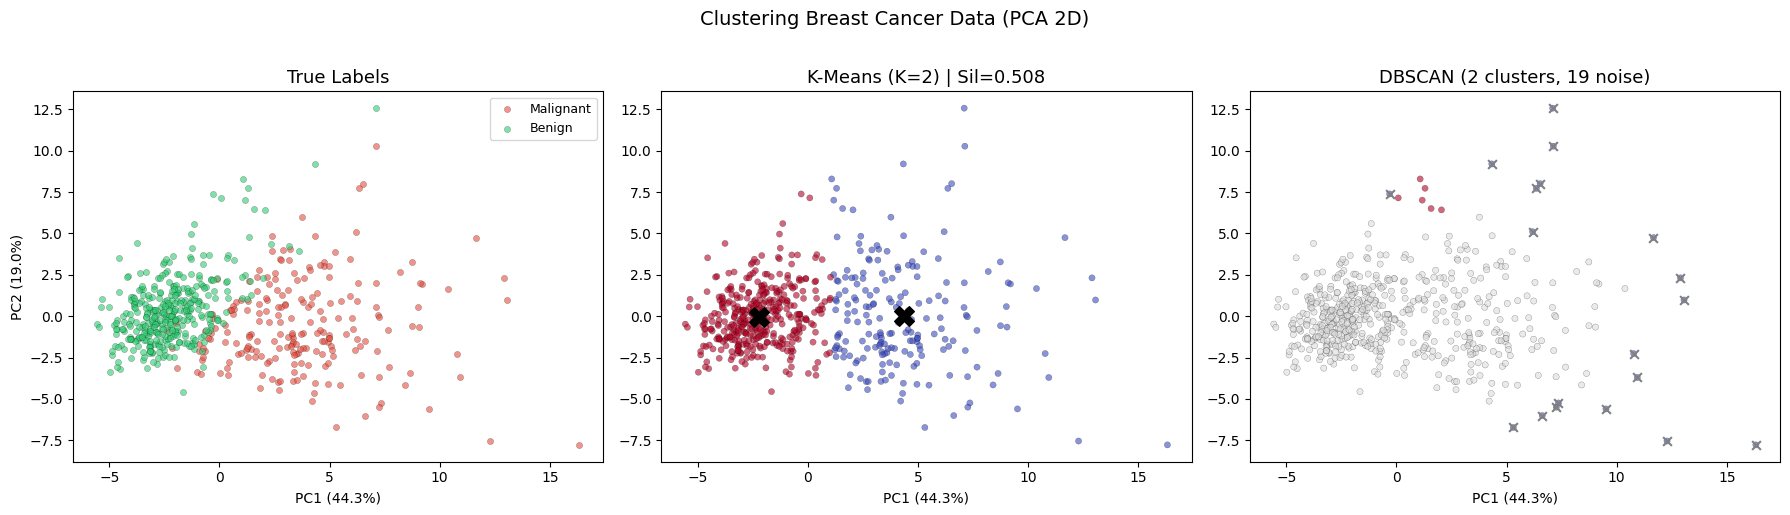

In [19]:
# Load Breast Cancer dataset

# Scale with StandardScaler

# Apply PCA with 2 components

# Fit KMeans(n_clusters=2) on PCA-transformed data

# Fit DBSCAN(eps=1.5, min_samples=5) on PCA-transformed data

# Create a figure with 1 row, 3 columns, figsize=(18, 5)
#   Left: True labels (y)
#   Middle: K-Means clusters
#   Right: DBSCAN clusters

# Show the plot


cancer = load_breast_cancer(as_frame=True)
X_real = cancer.data
y_real = cancer.target

scaler_real = StandardScaler()
X_real_sc = scaler_real.fit_transform(X_real)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_real_sc)

# K-Means
km_real = KMeans(n_clusters=2, random_state=42, n_init=10)
km_real_labels = km_real.fit_predict(X_pca)

# DBSCAN
db_real = DBSCAN(eps=1.5, min_samples=5)
db_real_labels = db_real.fit_predict(X_pca)
n_clusters_db = len(set(db_real_labels)) - (1 if -1 in db_real_labels else 0)
n_noise_db = (db_real_labels == -1).sum()

var = pca_2d.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True labels
for label, color, name in [(0, '#e74c3c', 'Malignant'), (1, '#2ecc71', 'Benign')]:
    mask = y_real == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=20,
                     alpha=0.6, label=name, edgecolors='k', linewidth=0.2)
axes[0].set_title('True Labels', fontsize=13)
axes[0].set_xlabel(f'PC1 ({var[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var[1]:.1f}%)')
axes[0].legend(fontsize=9)

# K-Means
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_real_labels, cmap='coolwarm',
                s=20, alpha=0.6, edgecolors='k', linewidth=0.2)
axes[1].scatter(km_real.cluster_centers_[:, 0], km_real.cluster_centers_[:, 1],
                c='black', marker='X', s=200, zorder=5)
axes[1].set_title(f'K-Means (K=2) | Sil={silhouette_score(X_pca, km_real_labels):.3f}', fontsize=13)
axes[1].set_xlabel(f'PC1 ({var[0]:.1f}%)')

# DBSCAN
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=db_real_labels, cmap='coolwarm',
                s=20, alpha=0.6, edgecolors='k', linewidth=0.2)
noise_mask = db_real_labels == -1
if noise_mask.any():
    axes[2].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                     c='grey', marker='x', s=40)
axes[2].set_title(f'DBSCAN ({n_clusters_db} clusters, {n_noise_db} noise)', fontsize=13)
axes[2].set_xlabel(f'PC1 ({var[0]:.1f}%)')

plt.suptitle('Clustering Breast Cancer Data (PCA 2D)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 11.1 How Well Did Clustering Match the True Labels?

Since we actually have the true labels, we can check how well the clusters correspond to malignant/benign. Note: cluster labels (0, 1) may be **flipped** compared to the true labels — clustering does not know which cluster is "malignant." We just check if the groups match.

**Task:** Compare cluster assignments with true labels.

In [20]:
# For K-Means:
#   Create a cross-tabulation: pd.crosstab(y, kmeans_labels,
#                              rownames=['True'], colnames=['KMeans Cluster'])
#   Print the table

# For DBSCAN:
#   Create the same cross-tabulation
#   Print the table
#   Print the number of noise points

# Compute silhouette scores for both

print("K-Means Cluster vs True Labels:")
print("=" * 40)
km_cross = pd.crosstab(y_real, km_real_labels,
                         rownames=['True Label'],
                         colnames=['KMeans Cluster'])
km_cross.index = ['Malignant (0)', 'Benign (1)']
print(km_cross)

sil_km = silhouette_score(X_pca, km_real_labels)
print(f"\nSilhouette Score: {sil_km:.4f}")

print(f"\n\nDBSCAN Cluster vs True Labels:")
print("=" * 40)
db_cross = pd.crosstab(y_real, db_real_labels,
                         rownames=['True Label'],
                         colnames=['DBSCAN Cluster'])
db_cross.index = ['Malignant (0)', 'Benign (1)']
print(db_cross)
print(f"\nNoise points: {n_noise_db}")
if n_clusters_db >= 2 and n_noise_db < len(y_real):
    non_noise = db_real_labels != -1
    if len(set(db_real_labels[non_noise])) >= 2:
        sil_db = silhouette_score(X_pca[non_noise], db_real_labels[non_noise])
        print(f"Silhouette Score (excl. noise): {sil_db:.4f}")

K-Means Cluster vs True Labels:
KMeans Cluster    0    1
Malignant (0)   175   37
Benign (1)       16  341

Silhouette Score: 0.5085


DBSCAN Cluster vs True Labels:
DBSCAN Cluster  -1    0   1
Malignant (0)   16  196   0
Benign (1)       3  348   6

Noise points: 19
Silhouette Score (excl. noise): 0.4085


**What to observe:** The cross-tabulation shows how cluster assignments align with true labels. A good clustering will have most of one true class concentrated in one cluster. The alignment will not be perfect — clustering is unsupervised and the data has overlap — but a clear pattern should emerge.

---

## 12. Summary and Key Takeaways

**Clustering is Unsupervised:**
- No labels needed — the algorithm discovers groups on its own
- Evaluation is harder than supervised learning (no "correct" answer)
- Use silhouette score and domain knowledge to assess quality

**K-Means:**

| Aspect | Detail |
|--------|--------|
| How it works | Iteratively assigns points to nearest centroid, updates centroids |
| Cluster shape | Spherical (globular) |
| Must specify | K (number of clusters) |
| Finding K | Elbow method, Silhouette score |
| Speed | Very fast |
| Weakness | Cannot find non-spherical clusters, sensitive to outliers |

**DBSCAN:**

| Aspect | Detail |
|--------|--------|
| How it works | Finds dense regions separated by sparse regions |
| Cluster shape | Arbitrary (any shape) |
| Must specify | eps (radius) and min_samples |
| Finding params | Trial and error, k-distance plot |
| Speed | Slower than K-Means |
| Strength | Detects noise/outliers, no need to specify K |

**When to Use What:**
- **K-Means** — When you expect roughly spherical, evenly-sized clusters and know (or can estimate) K
- **DBSCAN** — When clusters have arbitrary shapes, varying densities, or when you need noise detection

**Important:** Always **scale** your data before clustering (both algorithms use distance).

**What comes next:** More advanced unsupervised techniques and model deployment.